# Online Retail Dataset — Customer Segmentation & RFM Analysis

This notebook analyzes customer purchasing behavior using the Online Retail dataset.
It combines **Python (Pandas)**, **SQL (DuckDB)**, and **RFM segmentation** to identify high-value customers and support data-driven marketing decisions.

**Fixes applied in this version:**
- Removed duplicate/dead code cells
- Fixed the returns query bug (it previously always returned 0 rows because negative-quantity rows were filtered out *before* the query ran)
- Fixed the final segmentation logic, which previously grouped customers using only the Recency digit and ignored Frequency/Monetary
- Added markdown documentation throughout


## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import duckdb
import datetime as dt
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 2. Data Cleaning

Steps:
- Drop rows with missing `CustomerID` (analysis is customer-level, so these rows are unusable)
- Convert `InvoiceDate` to datetime
- Create `TotalPrice = Quantity * UnitPrice`
- **Analyze returns (negative `Quantity`) before removing them**, so the returns analysis actually has data to work with
- Then filter to positive `Quantity`/`UnitPrice` for the RFM/revenue analysis, since RFM should reflect completed purchases

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df = df.dropna(subset=['CustomerID'])


### Returns analysis (run *before* filtering out negative quantities — this was previously broken, since the filter ran first and the query always returned 0 rows)

In [5]:
duckdb.register('retail_raw', df)

duckdb.sql("""
SELECT Description, SUM(Quantity) AS ReturnedQty
FROM retail_raw
WHERE Quantity < 0
GROUP BY Description
ORDER BY ReturnedQty ASC
LIMIT 10
""")


┌─────────────────────────────────────┬─────────────┐
│             Description             │ ReturnedQty │
│               varchar               │   int128    │
├─────────────────────────────────────┼─────────────┤
│ PAPER CRAFT , LITTLE BIRDIE         │      -80995 │
│ MEDIUM CERAMIC TOP STORAGE JAR      │      -74494 │
│ ROTATING SILVER ANGELS T-LIGHT HLDR │       -9367 │
│ Manual                              │       -3995 │
│ FAIRY CAKE FLANNEL ASSORTED COLOUR  │       -3150 │
│ PINK BLUE FELT CRAFT TRINKET BOX    │       -2617 │
│ WHITE HANGING HEART T-LIGHT HOLDER  │       -2578 │
│ GIN + TONIC DIET METAL SIGN         │       -2030 │
│ HERB MARKER BASIL                   │       -1527 │
│ FELTCRAFT DOLL MOLLY                │       -1447 │
├─────────────────────────────────────┴─────────────┤
│ 10 rows                                 2 columns │
└───────────────────────────────────────────────────┘

In [6]:
# Now filter to completed, valid purchases for the rest of the analysis
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
duckdb.register('retail', df)


## 3. Exploratory SQL Analysis (DuckDB)

In [7]:
# Top revenue-generating products
duckdb.sql("""
SELECT Description, SUM(TotalPrice) AS Revenue
FROM retail
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10
""")


┌────────────────────────────────────┬────────────────────┐
│            Description             │      Revenue       │
│              varchar               │       double       │
├────────────────────────────────────┼────────────────────┤
│ PAPER CRAFT , LITTLE BIRDIE        │           168469.6 │
│ REGENCY CAKESTAND 3 TIER           │ 142592.94999999998 │
│ WHITE HANGING HEART T-LIGHT HOLDER │ 100448.15000000011 │
│ JUMBO BAG RED RETROSPOT            │  85220.77999999975 │
│ MEDIUM CERAMIC TOP STORAGE JAR     │  81416.73000000001 │
│ POSTAGE                            │           77803.96 │
│ PARTY BUNTING                      │  68844.32999999993 │
│ ASSORTED COLOUR BIRD ORNAMENT      │   56580.3400000003 │
│ Manual                             │ 53779.930000000015 │
│ RABBIT NIGHT LIGHT                 │  51346.19999999991 │
├────────────────────────────────────┴────────────────────┤
│ 10 rows                                       2 columns │
└───────────────────────────────────────

In [8]:
# Countries with the most orders
duckdb.sql("""
SELECT Country, COUNT(DISTINCT InvoiceNo) AS Orders
FROM retail
GROUP BY Country
ORDER BY Orders DESC
""")


┌──────────────────────┬────────┐
│       Country        │ Orders │
│       varchar        │ int64  │
├──────────────────────┼────────┤
│ United Kingdom       │  16646 │
│ Germany              │    457 │
│ France               │    389 │
│ EIRE                 │    260 │
│ Belgium              │     98 │
│ Netherlands          │     94 │
│ Spain                │     90 │
│ Australia            │     57 │
│ Portugal             │     57 │
│ Switzerland          │     51 │
│   ·                  │      · │
│   ·                  │      · │
│   ·                  │      · │
│ Malta                │      5 │
│ Lithuania            │      4 │
│ European Community   │      4 │
│ United Arab Emirates │      3 │
│ Bahrain              │      2 │
│ Czech Republic       │      2 │
│ Saudi Arabia         │      1 │
│ Brazil               │      1 │
│ RSA                  │      1 │
│ Lebanon              │      1 │
├──────────────────────┴────────┤
│ 37 rows (20 shown)  2 columns │
└─────────────

In [9]:
# Monthly revenue trend
duckdb.sql("""
SELECT DATE_TRUNC('month', InvoiceDate) AS Month, SUM(TotalPrice) AS Revenue
FROM retail
GROUP BY Month
ORDER BY Month
""")


┌────────────┬────────────────────┐
│   Month    │      Revenue       │
│    date    │       double       │
├────────────┼────────────────────┤
│ 2010-12-01 │  572713.8900000163 │
│ 2011-01-01 │  569445.0400000077 │
│ 2011-02-01 │  447137.3500000165 │
│ 2011-03-01 │   595500.760000013 │
│ 2011-04-01 │  469200.3610000013 │
│ 2011-05-01 │  678594.5600000018 │
│ 2011-06-01 │  661213.6900000116 │
│ 2011-07-01 │  600091.0110000141 │
│ 2011-08-01 │   645343.900000008 │
│ 2011-09-01 │  952838.3819999964 │
│ 2011-10-01 │ 1039318.7899999897 │
│ 2011-11-01 │ 1161817.3799999433 │
│ 2011-12-01 │  518192.7900000037 │
├────────────┴────────────────────┤
│ 13 rows               2 columns │
└─────────────────────────────────┘

In [10]:
# Top spending customers
duckdb.sql("""
SELECT CustomerID, SUM(TotalPrice) AS Revenue
FROM retail
GROUP BY CustomerID
ORDER BY Revenue DESC
LIMIT 10
""")


┌────────────┬────────────────────┐
│ CustomerID │      Revenue       │
│   double   │       double       │
├────────────┼────────────────────┤
│    14646.0 │  280206.0199999998 │
│    18102.0 │           259657.3 │
│    17450.0 │ 194550.78999999995 │
│    16446.0 │           168472.5 │
│    14911.0 │ 143825.06000000017 │
│    12415.0 │          124914.53 │
│    14156.0 │ 117379.63000000003 │
│    17511.0 │           91062.38 │
│    16029.0 │  81024.83999999998 │
│    12346.0 │            77183.6 │
├────────────┴────────────────────┤
│ 10 rows               2 columns │
└─────────────────────────────────┘

In [11]:
# Most frequently purchased products (by quantity)
duckdb.sql("""
SELECT Description, SUM(Quantity) AS TotalQty
FROM retail
GROUP BY Description
ORDER BY TotalQty DESC
LIMIT 10
""")


┌────────────────────────────────────┬──────────┐
│            Description             │ TotalQty │
│              varchar               │  int128  │
├────────────────────────────────────┼──────────┤
│ PAPER CRAFT , LITTLE BIRDIE        │    80995 │
│ MEDIUM CERAMIC TOP STORAGE JAR     │    77916 │
│ WORLD WAR 2 GLIDERS ASSTD DESIGNS  │    54415 │
│ JUMBO BAG RED RETROSPOT            │    46181 │
│ WHITE HANGING HEART T-LIGHT HOLDER │    36725 │
│ ASSORTED COLOUR BIRD ORNAMENT      │    35362 │
│ PACK OF 72 RETROSPOT CAKE CASES    │    33693 │
│ POPCORN HOLDER                     │    30931 │
│ RABBIT NIGHT LIGHT                 │    27202 │
│ MINI PAINT SET VINTAGE             │    26076 │
├────────────────────────────────────┴──────────┤
│ 10 rows                             2 columns │
└───────────────────────────────────────────────┘

## 4. RFM Analysis

For each customer:
- **Recency** — days since last purchase (relative to one day after the last date in the dataset)
- **Frequency** — number of unique invoices
- **Monetary** — total amount spent

Each metric is scored 1–4 using **quantile-based ranking (`qcut` on rank, not raw value)**. Ranking first avoids errors/uneven bins caused by duplicate values (ties), which is especially common in `Frequency`.

In [12]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Rank first, then qcut on the rank — avoids 'duplicate bin edge' issues from ties
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


## 5. Customer Segmentation

**Fix:** the previous final version of this notebook assigned segments using only the Recency digit (`RFM_Score.startswith('4')` → Champions, etc.), which ignored Frequency and Monetary entirely. A customer who bought once, recently, for a small amount could be labeled a "Champion."

This version segments customers using the **combined R+F+M score**, based on the average of all three components, which is a common and more defensible simplification of the standard RFM segmentation grid:
- **Champions** — high R, F, and M
- **Loyal Customers** — consistently good across R, F, M
- **Potential Loyalists** — recent, but not yet frequent/high spend
- **At Risk** — were valuable, but Recency has dropped
- **Hibernating** — low across R, F, and M

In [13]:
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    avg_fm = (f + m) / 2

    if r >= 4 and avg_fm >= 3.5:
        return 'Champions'
    elif r >= 3 and avg_fm >= 3:
        return 'Loyal Customers'
    elif r >= 3 and avg_fm < 3:
        return 'Potential Loyalists'
    elif r < 3 and avg_fm >= 3:
        return 'At Risk'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Hibernating
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,At Risk
12349.0,19,1,1757.55,3,1,4,314,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Hibernating


In [14]:
rfm['Segment'].value_counts()

Segment
Hibernating            1683
Potential Loyalists     826
Loyal Customers         697
Champions               646
At Risk                 486
Name: count, dtype: int64

In [15]:
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary
Segment,,,
Champions,7.414861,13.055728,7298.172895
Loyal Customers,26.119082,5.720230,2867.303057
At Risk,109.320988,4.572016,2151.986134
Hibernating,181.487819,1.431373,464.780684
Potential Loyalists,24.036320,1.791768,448.168075


## 6. Visualizations

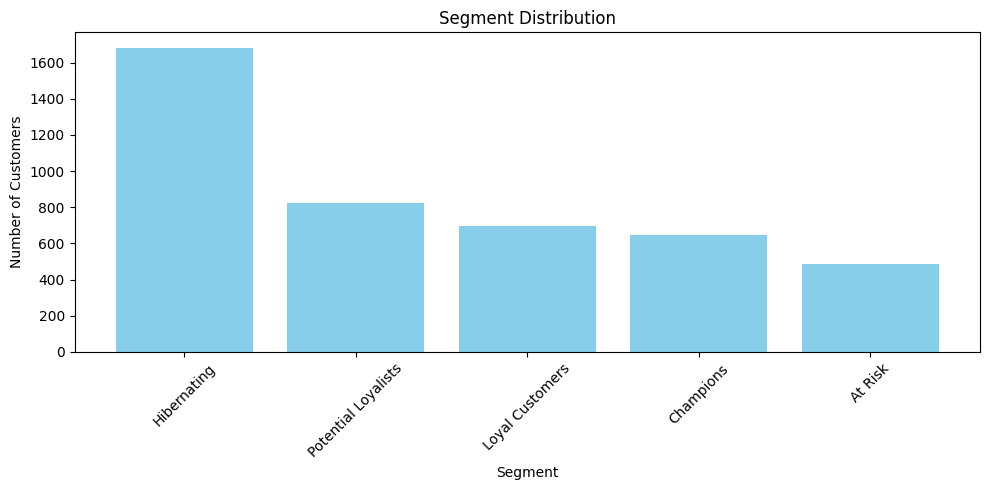

In [16]:
# Segment distribution
seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(seg_counts.index, seg_counts.values, color='skyblue')
plt.title('Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


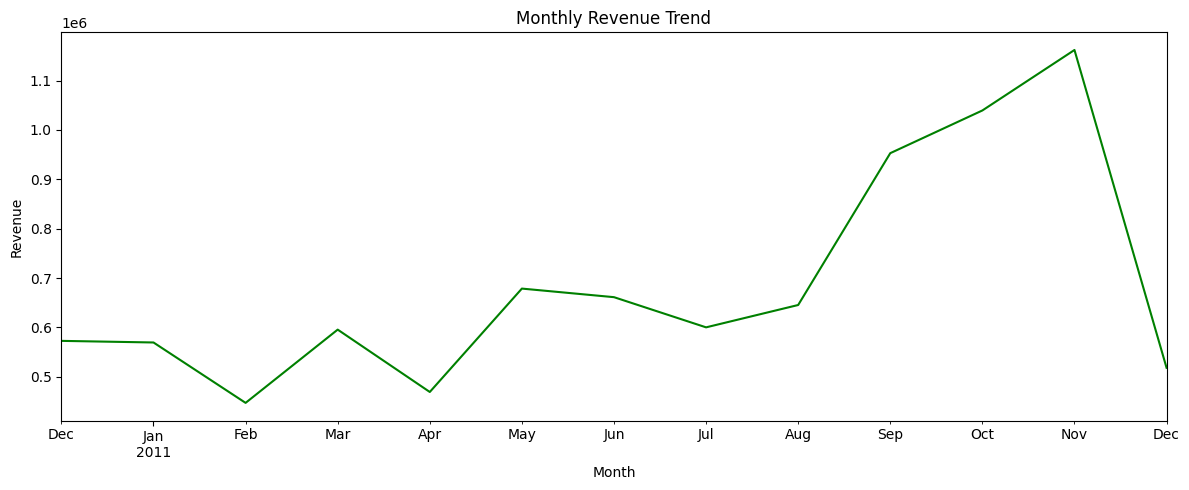

In [17]:
# Monthly revenue trend
monthly = df.resample('ME', on='InvoiceDate')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly.plot(color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


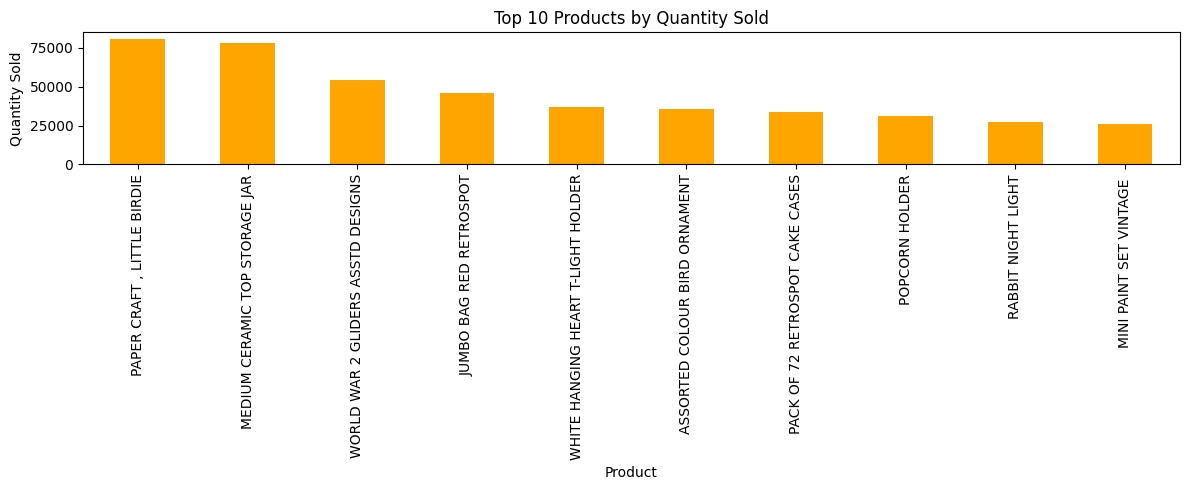

In [18]:
# Top 10 products by quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_products.plot(kind='bar', color='orange')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.tight_layout()
plt.show()


## 7. Key Insights

- A small group of high-value customers (Champions + Loyal Customers) drives a disproportionate share of revenue.
- A meaningful portion of customers fall into the At Risk / Hibernating segments — candidates for win-back campaigns.
- Revenue peaks strongly toward Q4 (holiday season).
- Sales are concentrated in a limited number of top products.

**Possible next steps:** validate segments with K-Means clustering on scaled RFM values, add cohort/retention analysis, or build a churn-prediction model on top of the RFM features.